# Practice Problem 1 - PCA Analysis

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#from sklearn.covariance import empirical_covariance

Shape of spectra_red:  (50000, 2676)
Shape of wavelength_grid_red:  (2676,)


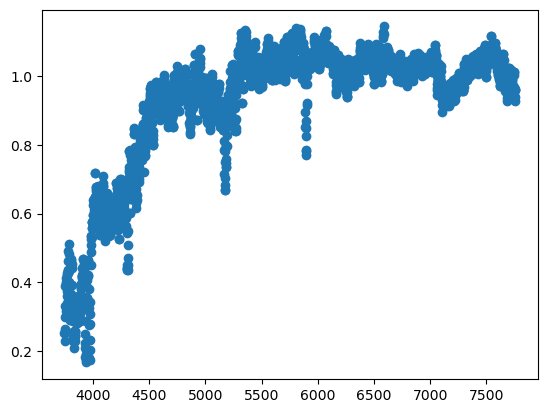

In [26]:
# Load in the data
spectra_red = np.load('/Users/kassidylam/UCSC/research/Ocean_Color/summer25/PCA_practice/habs/spectra_red.npy')
wavelength_grid_red = np.load('/Users/kassidylam/UCSC/research/Ocean_Color/summer25/PCA_practice/habs/wavelength_grid_red.npy')

# Check shape of data
print("Shape of spectra_red: ", spectra_red.shape)    #(50000 = galaxy spectra, 2676 = corresponding unique wavelength)
print("Shape of wavelength_grid_red: ", wavelength_grid_red.shape)    #(2676, )

# Choosing a random galaxy spectra to check if data is loaded properly
plt.scatter(wavelength_grid_red, spectra_red[100,:])
plt.show()

# a. Perform a “full” PCA analysis on these data (number of components equal to number of dimensions) and then: --> 2676 components then...

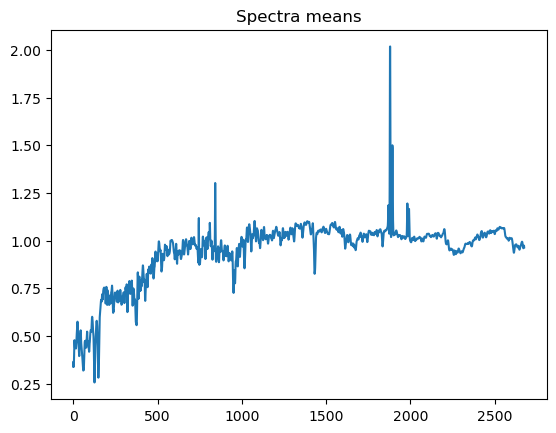

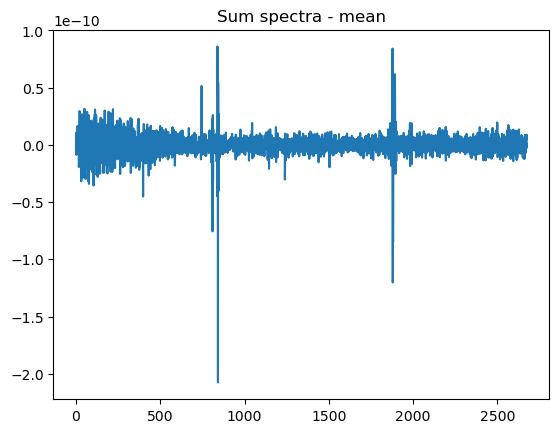

In [61]:
# 1) First center data by calculating and subtracting by mean
#spectra_mean_ = np.mean(spectra_red[:,0]) 
#print("Galaxy spectra mean: ", spectra_mean)   #0.3389
#wavelength_mean = np.mean(spectra_red[0,:])
#print("Spectra red wavelength mean: ", wavelength_mean)  #0.9624

# Standardize the data 
# Method 1
spectra_red = spectra_red.astype(np.float64)  # Ensure input is float64
scaler = StandardScaler()
standardized_spectra_red = scaler.fit_transform(spectra_red)

# Method 2
# spectra_red = spectra_red.astype(np.float64) # Get data overload if don't do this
# spectra_mean = np.mean(spectra_red, axis=0)
# spectra_std = np.std(spectra_red, axis=0)

# standardized_spectra_red = (spectra_red - spectra_mean) / spectra_std
plt.plot(spectra_mean)
plt.title("Spectra means")
plt.show()

plt.plot(sum(spectra_red - spectra_mean))
plt.title("Sum spectra - mean")
plt.show()
#print(standardized_spectra_red.shape)
#print("Centered galaxy spectra: ", centered_spectras)

#centered_wavelengths = spectra_red[0,:] - wavelength_mean
#print("Centered spectra wavelengths: ", centered_wavelengths)

#print("Standardized new_spectra_red: ", new_spectra_red)


In [62]:
# 2) Solve for the covariance matrix
#covariance_matrix = empirical_covariance(spectra_red)  #np.cov?
# covariance_matrix = np.cov(spectra_red.T)
covariance_matrix = np.cov(standardized_spectra_red, rowvar=False) #since rows and variables

pca = PCA(n_components = len(spectra_red[0,:]))
pca_fit = pca.fit(standardized_spectra_red)
#print("Covariance matrix: ", covariance_matrix) 

# Spectras variance
# for k in centered_spectras:
#     squared_centered_spectras = []
#     squared_s = k**2
#     squared_centered_spectras.append(squared_s)
#     sum_squared_spectras = sum(squared_centered_spectras)
#     spectras_variance = sum_squared_spectras/49999

# # Wavelengths variance
# for l in centered_wavelengths:
#     squared_centered_wavelengths = []
#     squared_wls = l**2
#     squared_centered_wavelengths.append(squared_wls)
#     sum_squared_centered_wls = sum(squared_centered_wavelengths)
#     wavelengths_variance = sum_squared_centered_wls/2675

# # Covariance
# for m in centered_spectras:
#     for n in centered_wavelengths:
#         products = []
#         spectras_times_wavelengths = m * n
#         products.append(spectras_times_wavelengths)
#         sum_products = sum(products)
#         sum_products/ # --> what is the sample size here??, figured out covariance matrix funtion is built in to package


In [63]:
# 3. Solve for the eigenvalues and eigenvectors of the covariance matrix
#eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
eigenvectors = pca_fit.components_
eigenvalues = pca_fit.explained_variance_
#print(covariance_matrix.shape)
#print("Eigenvalues: ", eigenvalues, "Eigenvectors: ", eigenvectors)
#print(eigenvalues.shape, eigenvectors.shape)
#index_max_eigenvalue = np.argmax(eigenvalues)
#print("Location of largest eigenvalue: ", index_max_eigenvalue)
#print("Eigenvector with largest eigenvalue: ", eigenvectors[:,0])


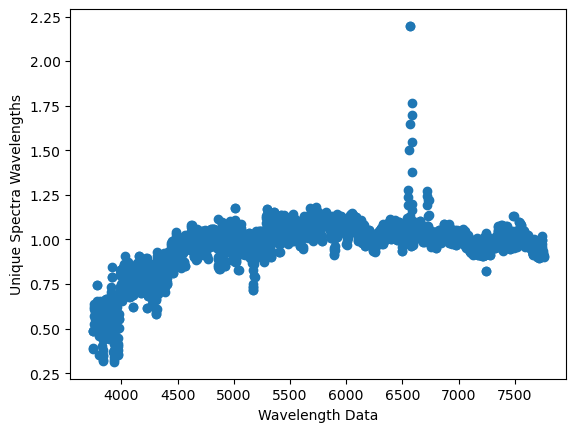

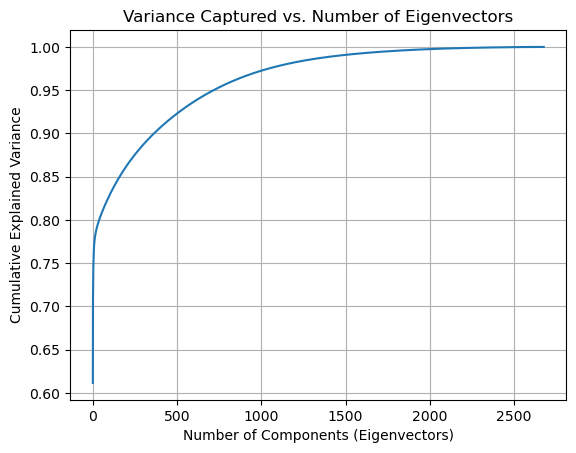

In [64]:
# i. Plot the variance captured as a function of the number of (ordered) eigenvectors.  How many eigenvectors do you need to explain ~95% of the variance in the data?
# eigenvectors = directions of new principal components

# Order the eigenvalues so that they go from highest to lowest values
descending_order = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[descending_order]
eigenvectors = eigenvectors[:, descending_order]
# print("Eigenvalues: ", eigenvalues)
#print("Eigenvectors: ", eigenvectors)

# Find the variances of the covariance matrix
# Principal components = eigenvectors
# Amount of variance from each PC = eigenvalue
# variances = np.diag(covariance_matrix)
# print("Variances: ", variances)

# Calculate variance for each PC
plt.scatter(wavelength_grid_red, spectra_red[0,:])
plt.xlabel("Wavelength Data")
plt.ylabel("Unique Spectra Wavelengths")
plt.show()

# components = pca.transform(standardized_spectra_red)
# projected = pca.inverse_transform(components)
# pca.fit_transform(standardized_spectra_red)

# standardized_spectra_red = (spectra_red - spectra_mean) / spectra_std, ... can also do pca.fit_transform of transpose
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
#print("Explained_variance_ratio: ", explained_variance_ratio)

# More efficient way to plot
plt.plot(cumulative_variance)
plt.xlabel("Number of Components (Eigenvectors)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Variance Captured vs. Number of Eigenvectors")
plt.grid()
plt.show()

# plt.figure(figsize=(12, 4))
# plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='-')
# plt.xlabel("Number of Components (Eigenvectors)")
# plt.ylabel("Cumulative Explained Variance")
# plt.title("Variance Captured vs. Number of Eigenvectors")
# plt.grid()
# plt.show()


Optimal Eigenvectors;  718
Transformed data shape:  (50000, 2676)


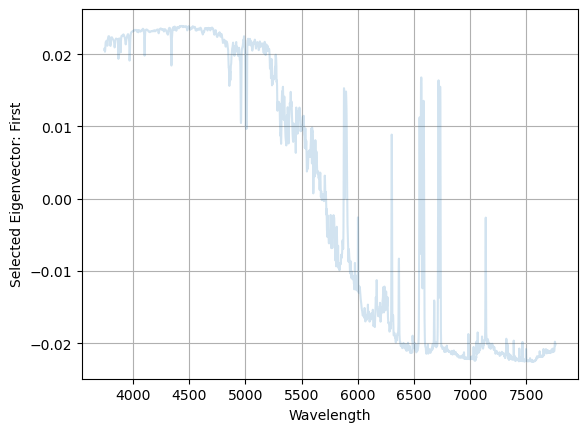

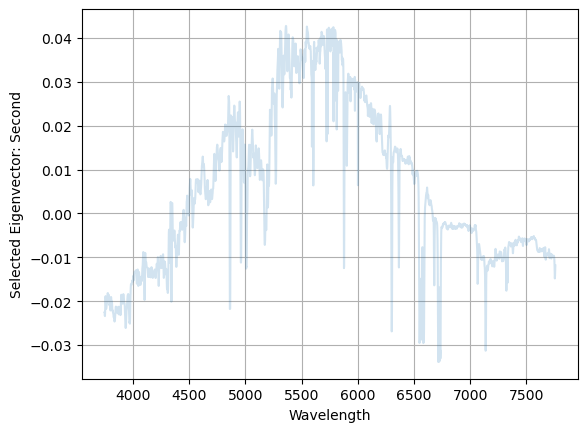

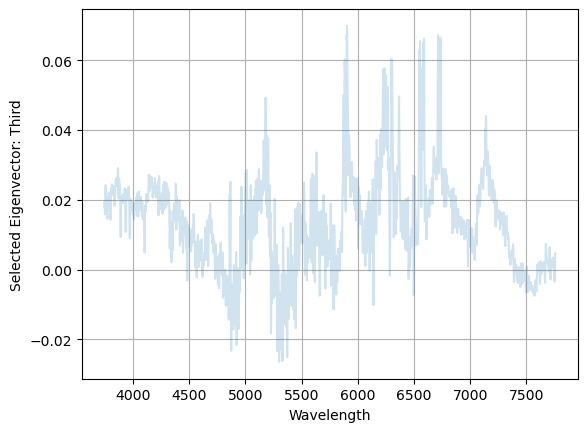

In [65]:
# ii. Plot the top several eigenvectors. Can you offer any physical explanations for what you find? Do you see any non-physical behavior?

# Checking how many eigenvectors should be kept to capture ~95% variance
eigenvectors_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Optimal Eigenvectors; ", eigenvectors_95)
# Plot first few eigenvectors against wavelength

# Transform data to new feature space
transformed = np.dot(standardized_spectra_red, eigenvectors_95)
print("Transformed data shape: ", transformed.shape)
plt.plot(wavelength_grid_red, eigenvectors[0], ls='-', alpha=0.2)
plt.xlabel("Wavelength")
plt.ylabel("Selected Eigenvector: First")
plt.grid()
plt.show()

plt.plot(wavelength_grid_red, eigenvectors[1], ls='-', alpha=0.2)
plt.xlabel("Wavelength")
plt.ylabel("Selected Eigenvector: Second")
plt.grid()
plt.show()

plt.plot(wavelength_grid_red, eigenvectors[2], ls='-', alpha=0.2)
plt.xlabel("Wavelength")
plt.ylabel("Selected Eigenvector: Third")
plt.grid()
plt.show()

# b. Now perform a PCA analysis with only a handful of components (justify your choice).

In [79]:
# Choose based on explained variance ratio
# Variance reaches ~95% --> do PCA analysis with first 718 components 

# 1) Data already standardized above

# 2) Chosen components
pca = PCA(n_components=718)
# Train model using input data and produce learned model
handful_fit = pca.fit_transform(standardized_spectra_red)  # fit_transform learns from the data and applies it
#print(handful_fit.shape)

# 3) Explained variance
new_explained_var_ratio = pca.explained_variance_ratio_
new_cumulative_var_ratio = np.cumsum(explained_variance_ratio)

(50000, 718)


(50000, 718)


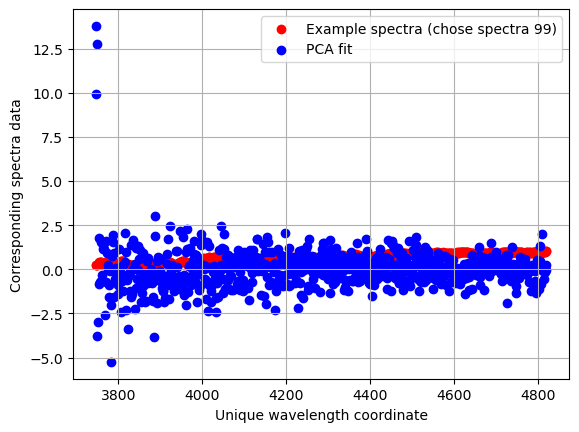

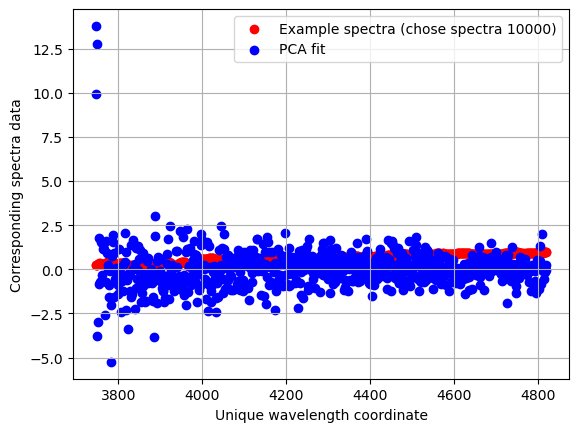

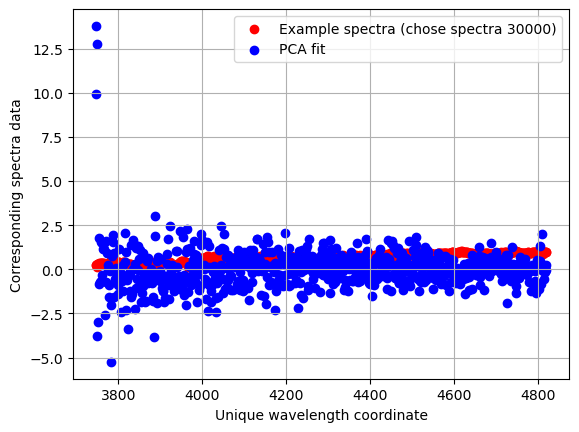

In [81]:
# i. Plot a few example spectra and your PCA fit.  How well is the data explained by the model?
# First 718 features
updated_wavelength_grid_red = wavelength_grid_red[0:718,]
updated_spectra_red = spectra_red[:, 0:718]
print(updated_spectra_red.shape)
plt.scatter(updated_wavelength_grid_red, updated_spectra_red[100,:], color='r')
plt.scatter(updated_wavelength_grid_red, handful_fit[100,:], color='b')
plt.xlabel("Unique wavelength coordinate")
plt.ylabel("Corresponding spectra data")
plt.legend(labels=["Example spectra (chose spectra 99)", "PCA fit"])
plt.grid()
plt.show()

plt.scatter(updated_wavelength_grid_red, updated_spectra_red[10001,:], color='r')
plt.scatter(updated_wavelength_grid_red, handful_fit[10001,:], color='b')
plt.xlabel("Unique wavelength coordinate")
plt.ylabel("Corresponding spectra data")
plt.legend(labels=["Example spectra (chose spectra 10000)", "PCA fit"])
plt.grid()
plt.show()

plt.scatter(updated_wavelength_grid_red, updated_spectra_red[30001,:], color='r')
plt.scatter(updated_wavelength_grid_red, handful_fit[30001,:], color='b')
plt.xlabel("Unique wavelength coordinate")
plt.ylabel("Corresponding spectra data")
plt.legend(labels=["Example spectra (chose spectra 30000)", "PCA fit"])
plt.grid()
plt.show()

(2676,)


ValueError: x and y must be the same size

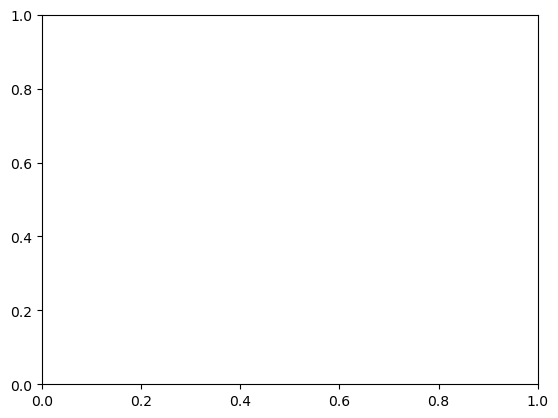

In [67]:
# ii. Plot the first two eigenvalues for every galaxy.  Can you make sense of the distribution?
# Chose 718 features
updated_eigenvalues = eigenvalues[0:1]
print(eigenvalues.shape)
plt.scatter(updated_wavelength_grid_red, eigenvalues)
plt.show()


In [ ]:
# iii. Explore a few of the features that you see.